## Preparation

In [1]:
from dataclasses import dataclass
from typing import Optional, Dict, Any
from collections import defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
from tqdm.auto import tqdm

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy.interpolate import UnivariateSpline, PchipInterpolator

import torch
from torch import nn
from torch.nn import functional as F
from torch.optim import Optimizer, Adam, Adagrad
from torch.distributions import MultivariateNormal
from torch.distributions.uniform import Uniform
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import WeightedRandomSampler

torch.manual_seed(12345)
random_state = 12345

In [2]:
plt.style.use("ggplot")
color = plt.rcParams["axes.prop_cycle"].by_key()
cd = {
    "red": "#E24A33",
    "gray": "#777777",
    "blue": "#348ABD",
    "green": "#8EBA42"
}
colors = [cd["red"], cd["blue"], cd["gray"], cd["green"]]

cmap_long_short = ListedColormap(LinearSegmentedColormap.from_list("long_short", [cd["green"], cd["red"]])(torch.linspace(0, 1, 6))).colors
cmap_epsilon_greedy = ListedColormap(LinearSegmentedColormap.from_list("epsilon_greedy", [cd["green"], cd["blue"]])(torch.linspace(0, 1, 6))).colors

## dataload

In [3]:
# If you are running locally, make sure you are in the directory of KuaiRec.
rootpath="./"

In [4]:
# from google.colab import drive
drive.mount('/content/drive')

rootpath="./drive/MyDrive/_datasets/KuaiRec/" # Make sure this path corresponds to KuaiRec in your Drive.

Mounted at /content/drive


In [5]:
print("Loading small matrix...")
small_matrix = pd.read_csv(rootpath + "data/small_matrix.csv")

# print("Loading big matrix...")
# big_matrix = pd.read_csv(rootpath + "data/big_matrix.csv")

# clip values
small_matrix["watch_ratio"] = small_matrix["watch_ratio"].clip(lower=0, upper=10)

# re-index user and content ids
small_matrix["user_id"] = pd.factorize(small_matrix["user_id"])[0]
small_matrix["video_id"] = pd.factorize(small_matrix["video_id"])[0]


# small_matrix.head()
# plt.hist(small_matrix["watch_ratio"], bins=torch.logspace(0, 1, 20))

Loading small matrix...


In [6]:
small_matrix["user_id"].nunique()

1411

In [7]:
small_matrix["video_id"].max()

3326

In [8]:
len(small_matrix)

4676570

## data preprocessing

In [9]:
def torch_seed(random_state: int, device: str = "cpu"):
    if device != "cpu":
        torch.cuda.manual_seed(random_state)

    torch.manual_seed(random_state)

In [10]:
class KuaiRecDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        user_id_column: str = "user_id",
        content_id_column: str = "video_id",
        reward_column: str = "watch_ratio",
        device: Optional[str] = None,
    ):
        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device

        user_id = df[user_id_column].values
        content_id = df[content_id_column].values
        reward = df[reward_column].values

        self.user_id = torch.LongTensor(user_id).to(device)
        self.content_id = torch.LongTensor(content_id).to(device)
        self.reward = torch.FloatTensor(reward).to(device)

    def __len__(self):
        return len(self.user_id)

    def __getitem__(self, idx: int):
        batch = {
            "user_id": self.user_id[idx],
            "content_id": self.content_id[idx],
            "reward": self.reward[idx],
        }
        return batch


In [11]:
class CollaborativeFilteringModel(nn.Module):
    def __init__(
        self,
        n_users: int,
        n_contents: int,
        dim_emb: int = 10,
        hidden_dim: int = 100,
        device: str = "cuda",
        random_state: Optional[int] = None,
    ):
        super().__init__()
        self.loss_fn = nn.MSELoss()
        self.device = device

        if random_state is not None:
            torch_seed(random_state, device=self.device)

        self.user_embedding = nn.Embedding(n_users, dim_emb).to(device)
        self.content_embedding = nn.Embedding(n_contents, dim_emb).to(device)

        self.l1 = nn.Linear(2 * dim_emb, hidden_dim).to(device)
        self.l2 = nn.Linear(hidden_dim, 1).to(device)
        self.relu = nn.ReLU()

        self.user_bias = nn.Embedding(n_users, 1).to(device)
        self.content_bias = nn.Embedding(n_contents, 1).to(device)

        self.softplus = nn.Softplus()

        nn.init.kaiming_normal_(self.l1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.l2.weight, nonlinearity='relu')

    def forward(
        self,
        user_id: torch.Tensor,     # (batch_size, )
        content_id: torch.Tensor,  # (batch_size, )
    ):
        user_id = user_id.to(self.device)
        content_id = content_id.to(self.device)

        user_embedding = self.user_embedding(user_id)
        content_embedding = self.content_embedding(content_id)

        x = torch.cat((user_embedding, content_embedding), dim=1)
        x = self.relu(self.l1(x))
        interaction = self.l2(x).squeeze()

        user_bias = self.user_bias(user_id).squeeze(1)
        content_bias = self.content_bias(content_id).squeeze(1)

        logits = interaction + user_bias + content_bias
        return self.softplus(logits)

    def mse_loss(
        self,
        user_id: torch.Tensor,     # (batch_size, )
        content_id: torch.Tensor,  # (batch_size, )
        reward: torch.Tensor,      # (batch_size, )
    ):
        reward = reward.to(self.device)
        prediction = self(user_id, content_id)
        return self.loss_fn(prediction, reward)


In [12]:
def train_cf_model(model: nn.Module, df: pd.DataFrame):
    n_epochs = 1000
    n_steps_per_epoch = 10
    batch_size = 32
    val_ratio = 0.2

    train_df, val_df = train_test_split(
        df, test_size=val_ratio, shuffle=True, random_state=random_state,
    )

    train_dataset = KuaiRecDataset(train_df)
    val_dataset = KuaiRecDataset(val_df)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses = torch.zeros((n_epochs + 1,))
    val_losses = torch.zeros((n_epochs + 1,))

    early_stopping_cnt = 0
    optimizer = Adam(model.parameters(), lr=1e-4)

    with tqdm(torch.arange(n_epochs)) as pbar:
        for i, ch in enumerate(pbar):
            pbar.set_description(f"[finetune reward simulator: Epoch {i + 1}]")
            pbar.set_postfix(
                {
                    "train_loss": f"{train_losses[i]:.4g}",
                    "val_loss": f"{val_losses[i]:.4g}",
                }
            )

            if early_stopping_cnt >= 5:
                print(f"apply early stopping at epoch {i + 1}")
                break

            train_iterator = iter(train_dataloader)

            for j in range(n_steps_per_epoch):
                batch_ = next(train_iterator)
                user_id_ = batch_["user_id"].to(device=model.device)
                content_id_ = batch_["content_id"].to(model.device)
                reward_ = batch_["reward"].to(model.device)

                train_loss = model.mse_loss(user_id_, content_id_, reward_)
                optimizer.zero_grad()
                train_loss.backward()
                optimizer.step()

                train_losses[i + 1] += train_loss.item() / n_steps_per_epoch

            for val_batch_ in val_dataloader:
                val_user_id_ = val_batch_["user_id"].to(model.device)
                val_content_id_ = val_batch_["content_id"].to(model.device)
                val_reward_ = val_batch_["reward"].to(model.device)

                val_loss_ = model.mse_loss(val_user_id_, val_content_id_, val_reward_)
                ratio_ = len(val_user_id_) / len(val_dataloader.dataset)
                val_losses[i + 1] += ratio_ * val_loss_.item()

        return model

In [13]:
def retrieve_user_and_content_infos(
    model: CollaborativeFilteringModel,
    n_users: int,
    n_contents: int,
    n_user_groups: int,
    n_content_groups: int,
):
    user_ids = torch.arange(n_users).to(model.device)
    content_ids = torch.arange(n_contents).to(model.device)
    user_embs = model.user_embedding(user_ids).cpu().detach()
    content_embs = model.content_embedding(content_ids).cpu().detach()

    user_kmeans = KMeans(n_clusters=n_user_groups, random_state=random_state)
    content_kmeans = KMeans(n_clusters=n_content_groups, random_state=random_state)
    user_cluster_ids = user_kmeans.fit_predict(user_embs)
    content_cluster_ids = content_kmeans.fit_predict(content_embs)
    return user_embs, content_embs, user_cluster_ids, content_cluster_ids

In [14]:
n_user_groups = 20
n_content_groups = 20

In [15]:
df = small_matrix[["user_id", "video_id", "watch_ratio"]]
n_users = df["user_id"].nunique()
n_contents = df["video_id"].nunique()

In [16]:
model = CollaborativeFilteringModel(
    n_users=n_users,
    n_contents=n_contents,
    device="cuda" if torch.cuda.is_available() else "cpu",
    random_state=random_state,
)

In [17]:
model.load_state_dict(torch.load(rootpath + "cf_model.pt"))

user_embs, content_embs, user_cluster_ids, content_cluster_ids = retrieve_user_and_content_infos(
    model,
    n_users=n_users,
    n_contents=n_contents,
    n_user_groups=n_user_groups,
    n_content_groups=n_content_groups,
)

## simulation modules

In [18]:
def sigmoid(z: torch.Tensor):
    return 1 / (1 + torch.exp(- z))

In [19]:
def concave_function(
    z: torch.Tensor,        # (input_dim, ) or (input_dim1, input_dim2)
    tau: torch.Tensor,      # (input_dim, ) or (input_dim1, input_dim2)
    max_val: torch.Tensor,  # (input_dim, ) or (input_dim1, input_dim2)
):
    return max_val * (sigmoid(z / tau) - 0.5)

In [20]:
@dataclass
class SemiSyntheticEnv:
    user_embs: torch.Tensor
    content_embs: torch.Tensor
    user_cluster_ids: torch.Tensor
    content_cluster_ids: torch.Tensor
    min_population: float = 1.0
    n_perms_to_approximate: int = 10
    random_state: Optional[int] = None

    def __post_init__(self, ):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)

        self.n_user_groups = self.user_cluster_ids.max() + 1
        self.n_content_groups = self.content_cluster_ids.max() + 1
        self.dim_emb = self.user_embs.shape[1]

        # user and content embeddings
        self.clustered_user_embs = []
        self.n_unique_users = torch.zeros((self.n_user_groups, ), dtype=int)
        for i in range(self.n_user_groups):
            user_ids_ = (self.user_cluster_ids == i).nonzero()
            self.clustered_user_embs.append(self.user_embs[user_ids_].mean(dim=0))  # avg user embeddings among the cluster
            self.n_unique_users[i] = len(user_ids_[0])

        self.clustered_content_embs = []
        self.n_unique_contents = torch.zeros((self.n_content_groups, ), dtype=int)
        for i in range(self.n_content_groups):
            content_ids_ = (self.content_cluster_ids == i).nonzero()
            self.clustered_content_embs.append(self.content_embs[content_ids_])
            self.n_unique_contents[i] = len(self.clustered_content_embs[i])

        # shuffled content ids
        self.shuffled_content_ids = []
        for i in range(self.n_content_groups):
            content_ids = torch.zeros((self.n_perms_to_approximate, self.n_unique_contents[i]), dtype=int)

            for j in range(self.n_perms_to_approximate):
                content_ids[j] = torch.randperm(self.n_unique_contents[i])

            self.shuffled_content_ids.append(content_ids)

        self.current_users = []
        for i in range(self.n_user_groups):
            self.current_users.append(None)

        self.current_contents = []
        for i in range(self.n_content_groups):
            self.current_contents.append(None)

        # user and content populations
        self.max_users = torch.clip(torch.normal(torch.full((n_user_groups, ), 200.), torch.full((n_user_groups, ), 50.)), min=100.)
        self.tau_users = torch.clip(torch.normal(torch.full((n_user_groups, ), 2.), torch.full((n_user_groups, ), 1.)), min=1.)


        self.max_contents = torch.clip(torch.normal(torch.full((n_content_groups, ), 200.), torch.full((n_content_groups, ), 50.)), min=100.)
        self.tau_contents = torch.clip(torch.normal(torch.full((n_content_groups, ), 20.), torch.full((n_content_groups, ), 1.)), min=1.)


        self.user_reactiveness = torch.clip(torch.normal(torch.full((n_user_groups, ), 0.1), torch.full((n_user_groups, ), 0.03)), min=0., max=1.)
        self.content_reactiveness = torch.clip(torch.normal(torch.full((n_content_groups, ), 0.1), torch.full((n_content_groups, ), 0.03)), min=0., max=1.)

        # base reward matrix
        self.base_utility_matrix = torch.zeros((self.n_user_groups, self.n_content_groups))
        for i in range(self.n_user_groups):
            for j in range(self.n_content_groups):
                enum_base_reward_ = torch.clip(self.clustered_user_embs[i] @ self.clustered_content_embs[j].T, min=0.)
                self.base_utility_matrix[i, j] = enum_base_reward_.mean()

        # fit reward model
        self.reward_models = self._fit_reward_model()

    def _fit_reward_model(
        self,
        n_samples_to_approximate: int = 1000,
    ):
        content_population_dist = Uniform(
            low=torch.full((self.n_content_groups, ), self.min_population),
            high=self.max_contents * 2,
        )
        content_population = content_population_dist.sample((n_samples_to_approximate, ))
        content_population = torch.sort(content_population, dim=0)[0]

        empirical_utility_matrix = torch.zeros((n_samples_to_approximate, self.n_user_groups, self.n_content_groups))
        for i in tqdm(range(n_samples_to_approximate)):
            empirical_utility_matrix[i] = self.empirical_utility_matrix(content_population[i])

        reward_models, reward_models_ = [], []
        for k in tqdm(range(self.n_user_groups * self.n_content_groups)):
            i = k // self.n_content_groups
            j = k % self.n_content_groups

            reward_models_.append(
                UnivariateSpline(content_population[:, j], empirical_utility_matrix[:, i, j], k=3)
            )

            if j == self.n_content_groups - 1:
                reward_models.append(reward_models_)
                reward_models_ = []

        return reward_models

    def empirical_utility_matrix(
        self,
        content_population: torch.Tensor,  # (n_content_groups, )
    ):
        for i in range(self.n_user_groups):
            self.current_users[i] = self.clustered_user_embs[i]

        empirical_utility_matrix = torch.zeros((self.n_perms_to_approximate, self.n_user_groups, self.n_content_groups))
        for k in range(self.n_perms_to_approximate):
            for i in range(self.n_content_groups):
                content_ids = torch.randint(self.n_unique_contents[i], (content_population[i].int(), ))
                content_ids = torch.arange(content_population[i].int(), ) % self.n_unique_contents[i]
                content_ids = self.shuffled_content_ids[i][k][content_ids]
                self.current_contents[i] = self.clustered_content_embs[i][content_ids]

            for i in range(self.n_user_groups):
                for j in range(self.n_content_groups):
                    enum_base_reward_ = torch.clip(self.current_users[i] @ self.current_contents[j].T, min=0.)
                    empirical_utility_matrix[k, i, j] = enum_base_reward_.max()

        return empirical_utility_matrix.mean(dim=0)

    def fitted_utility_matrix(
        self,
        content_population: torch.Tensor,  # (n_content_groups, )
    ):
        utility_matrix = torch.zeros((self.n_user_groups, self.n_content_groups))
        for i in range(self.n_user_groups):
            for j in range(self.n_content_groups):
                utility_matrix[i, j] = torch.FloatTensor(self.reward_models[i][j](content_population[j]))

        return utility_matrix

    def update_users_and_contents(
        self,
        user_population: torch.Tensor,     # (n_user_groups, )
        content_population: torch.Tensor,  # (n_content_groups, )
        user_utility: torch.Tensor,        # (n_user_groups, )
        content_exposure: torch.Tensor,    # (n_content_groups, )
    ):
        user_reference_population = concave_function(user_utility, tau=self.tau_users, max_val=self.max_users)
        content_reference_population = concave_function(content_exposure, tau=self.tau_contents, max_val=self.max_contents)

        user_pertubation = torch.normal(torch.zeros((self.n_user_groups, )), torch.full((self.n_user_groups, ), 0.01)) * user_population
        content_pertubation = torch.normal(torch.zeros((self.n_content_groups, )), torch.full((self.n_content_groups, ), 0.01)) * content_population

        user_population = torch.clip(
            (1 - self.user_reactiveness) * user_population + self.user_reactiveness * user_reference_population + user_pertubation,
            min=self.min_population,
        )
        content_population = torch.clip(
            (1 - self.content_reactiveness) * content_population + self.content_reactiveness * content_reference_population + content_pertubation,
            min=self.min_population,
        )
        utility_matrix = self.fitted_utility_matrix(content_population)

        return user_population, content_population, utility_matrix


In [21]:
def user_utility_fn(
    policy: torch.Tensor,          # (n_user_groups, n_content_groups)
    utility_matrix: torch.Tensor,  # (n_user_groups, n_content_groups)
):
    user_utility = (policy * utility_matrix).sum(dim=1)
    return user_utility

In [22]:
def content_exposure_fn(
    policy: torch.Tensor,           # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,  # (n_user_groups, )
):
    content_exposure = (policy * torch.tile(user_population, (n_content_groups, 1)).T).sum(dim=0)
    return content_exposure

In [23]:
env = SemiSyntheticEnv(
    user_embs=user_embs,
    content_embs=content_embs,
    user_cluster_ids=user_cluster_ids,
    content_cluster_ids=content_cluster_ids,
    random_state=random_state,
)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

## policy

In [24]:
def softmax(
    z: torch.Tensor,  # (n_dim1, n_dim_2)
):
    z = z - z.max(dim=1, keepdim=True)[0]
    return F.softmax(z, dim=1)

In [25]:
class DynamicsModelDataset(Dataset):
    def __init__(
        self,
        device: Optional[str] = None,
    ):
        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device

        self.user_population = []
        self.content_population = []
        self.utility_matrix = []
        self.prev_user_population = []
        self.prev_content_population = []
        self.prev_user_utility = []
        self.prev_content_exposure = []

    def __len__(self):
        return len(self.user_population)

    def __getitem__(self, idx: int):
        batch = {
            "user_population": self.user_population[idx],
            "content_population": self.content_population[idx],
            "utility_matrix": self.utility_matrix[idx],
            "prev_user_population": self.prev_user_population[idx],
            "prev_content_population": self.prev_content_population[idx],
            "prev_user_utility": self.prev_user_utility[idx],
            "prev_content_exposure": self.prev_content_exposure[idx],
        }
        return batch

    def append(
        self,
        user_population: torch.Tensor,          # (n_user_groups, )
        content_population: torch.Tensor,       # (n_content_groups, )
        utility_matrix: torch.Tensor,           # (n_user_groups, n_content_groups)
        prev_user_population: torch.Tensor,     # (n_user_groups, )
        prev_content_population: torch.Tensor,  # (n_content_groups, )
        prev_user_utility: torch.Tensor,        # (n_user_groups, )
        prev_content_exposure: torch.Tensor,    # (n_content_groups, )
    ):
        self.user_population.append(user_population.to(self.device))
        self.content_population.append(content_population.to(self.device))
        self.utility_matrix.append(utility_matrix.to(self.device))
        self.prev_user_population.append(prev_user_population.to(self.device))
        self.prev_content_population.append(prev_content_population.to(self.device))
        self.prev_user_utility.append(prev_user_utility.to(self.device))
        self.prev_content_exposure.append(prev_content_exposure.to(self.device))


In [26]:
class DynamicsModel(nn.Module):
    def __init__(
        self,
        n_user_groups: int,
        n_content_groups: int,
        device: Optional[str] = None,
        random_state: Optional[int] = None,
    ):
        super().__init__()
        self.n_user_groups = n_user_groups
        self.n_content_groups = n_content_groups
        self.loss_fn = nn.MSELoss()

        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device

        if random_state is not None:
            torch_seed(random_state, device=self.device)

        self.a0_users = nn.Parameter(torch.full((n_user_groups, ), 100., requires_grad=True)).to(device)
        self.a1_users = nn.Parameter(torch.full((n_user_groups, ), 1., requires_grad=True)).to(device)
        self.a2_users = nn.Parameter(torch.full((n_user_groups, ), 0.1, requires_grad=True)).to(device)
        self.a3_users = nn.Parameter(torch.full((n_user_groups, ), 1., requires_grad=True)).to(device)
        self.reactiveness_users = nn.Parameter(torch.zeros((n_user_groups, ), requires_grad=True)).to(device)

        self.a0_contents = nn.Parameter(torch.full((n_content_groups, ), 100., requires_grad=True)).to(device)
        self.a1_contents = nn.Parameter(torch.full((n_content_groups, ), 1., requires_grad=True)).to(device)
        self.a2_contents = nn.Parameter(torch.full((n_content_groups, ), 0.1, requires_grad=True)).to(device)
        self.a3_contents = nn.Parameter(torch.full((n_content_groups, ), 1., requires_grad=True)).to(device)
        self.reactiveness_contents = nn.Parameter(torch.zeros((n_content_groups, ), requires_grad=True)).to(device)

        self.a0_population = nn.Parameter(torch.full((n_user_groups, n_content_groups), 1., requires_grad=True)).to(device)
        self.a1_population = nn.Parameter(torch.full((n_user_groups, n_content_groups), 1., requires_grad=True)).to(device)
        self.a2_population = nn.Parameter(torch.full((n_user_groups, n_content_groups), 1., requires_grad=True)).to(device)
        self.a3_population = nn.Parameter(torch.full((n_user_groups, n_content_groups), 1., requires_grad=True)).to(device)

        self.softplus = nn.Softplus()

    def _estimate_population(
        self,
        estimated_ref_population: torch.Tensor,  # (input_dim, ) or (batch_size, input_dim)
        prev_population: torch.Tensor,           # (input_dim, ) or (batch_size, input_dim)
        reactiveness: torch.Tensor,              # (input_dim, ) or (batch_size, input_dim)
    ):
        if prev_population.ndim == 2:
            batch_size = prev_population.shape[0]
            reactiveness = reactiveness.unsqueeze(0).expand(batch_size, -1)

        # make sure that reactiveness is in [0, 1]
        reactiveness = sigmoid(reactiveness)

        estimated_population = (1 - reactiveness) * prev_population + reactiveness * estimated_ref_population
        return estimated_population

    def _concave_function(
        self,
        z: torch.Tensor,   # (input_dim, ) or (input_dim, input_dim)
        a0: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
        a1: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
        a2: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
        a3: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
    ):
        return torch.clip(a0 * (1 - torch.exp(- a1 * (z - a2))) + a3, min=0.)

    def _batch_concave_function(
        self,
        z: torch.Tensor,   # (batch_size, input_dim) or (batch_size, input_dim, input_dim)
        a0: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
        a1: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
        a2: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
        a3: torch.Tensor,  # (input_dim, ) or (input_dim, input_dim)
    ):
        batch_size = z.shape[0]

        if z.ndim == 2:
            a0 = a0.unsqueeze(0).expand(batch_size, -1)
            a1 = a1.unsqueeze(0).expand(batch_size, -1)
            a2 = a2.unsqueeze(0).expand(batch_size, -1)
            a3 = a3.unsqueeze(0).expand(batch_size, -1)

        else:
            a0 = a0.unsqueeze(0).expand(batch_size, -1, -1)
            a1 = a1.unsqueeze(0).expand(batch_size, -1, -1)
            a2 = a2.unsqueeze(0).expand(batch_size, -1, -1)
            a3 = a3.unsqueeze(0).expand(batch_size, -1, -1)

        return self.softplus(a0 * (1 - torch.exp(- a1 * (z - a2))) + a3)

    def forward(
        self,
        prev_user_population: torch.Tensor,     # (batch_size, n_user_groups)
        prev_content_population: torch.Tensor,  # (batch_size, n_content_groups, )
        prev_user_utility: torch.Tensor,        # (batch_size, n_user_groups, )
        prev_content_exposure: torch.Tensor,    # (batch_size, n_content_groups, )
    ):
        prev_user_population = prev_user_population.to(self.device)
        prev_content_population = prev_content_population.to(self.device)
        prev_user_utility = prev_user_utility.to(self.device)
        prev_content_exposure = prev_content_exposure.to(self.device)

        estimated_ref_user_population = self._batch_concave_function(
            prev_user_utility, a0=self.a0_users, a1=self.a1_users, a2=self.a2_users, a3=self.a3_users,
        )
        estimated_ref_content_population = self._batch_concave_function(
            prev_content_exposure, a0=self.a0_contents, a1=self.a1_contents, a2=self.a2_contents, a3=self.a3_contents,
        )

        prev_content_population = prev_content_population.unsqueeze(1).expand(-1, self.n_user_groups, -1)
        estimated_utility_matrix = self._batch_concave_function(
            prev_content_population, a0=self.a0_population, a1=self.a1_population, a2=self.a2_population, a3=self.a3_population,
        )

        return estimated_ref_user_population, estimated_ref_content_population, estimated_utility_matrix

    def mse_loss(
        self,
        user_population: torch.Tensor,          # (batch_size, n_user_groups, )
        content_population: torch.Tensor,       # (batch_size, n_content_groups, )
        utility_matrix: torch.Tensor,           # (batch_size, n_user_groups, n_content_groups)
        prev_user_population: torch.Tensor,     # (batch_size, n_user_groups, )
        prev_content_population: torch.Tensor,  # (batch_size, n_content_groups, )
        prev_user_utility: torch.Tensor,        # (batch_size, n_user_groups, )
        prev_content_exposure: torch.Tensor,    # (batch_size, n_content_groups, )
    ):
        user_population = user_population.to(self.device)
        content_population = content_population.to(self.device)
        prev_user_population = prev_user_population.to(self.device)
        prev_content_population = prev_content_population.to(self.device)
        utility_matrix = utility_matrix.to(self.device)

        estimated_ref_user_population, estimated_ref_content_population, estimated_utility_matrix = self(
            prev_user_population=prev_user_population,
            prev_content_population=prev_content_population,
            prev_user_utility=prev_user_utility,
            prev_content_exposure=prev_content_exposure,
        )
        estimated_user_population = self._estimate_population(
            estimated_ref_population=estimated_ref_user_population,
            prev_population=prev_user_population,
            reactiveness=self.reactiveness_users,
        )
        estimated_content_population = self._estimate_population(
            estimated_ref_population=estimated_ref_content_population,
            prev_population=prev_content_population,
            reactiveness=self.reactiveness_contents,
        )

        user_population_loss = self.loss_fn(estimated_user_population, user_population)
        content_population_loss = self.loss_fn(estimated_content_population, content_population)
        population_effect_loss = self.loss_fn(estimated_utility_matrix, utility_matrix)
        return user_population_loss, content_population_loss, population_effect_loss

    def estimate_reference_statistics(
        self,
        user_utility: torch.Tensor,        # (n_user_groups, )
        content_exposure: torch.Tensor,    # (n_content_groups, )
    ):
        user_reference_population = self._concave_function(
            user_utility,
            a0=self.a0_users.detach(), a1=self.a1_users.detach(), a2=self.a2_users.detach(), a3=self.a3_users.detach(),
        )
        content_reference_population = self._concave_function(
            content_exposure,
            a0=self.a0_contents.detach(), a1=self.a1_contents.detach(), a2=self.a2_contents.detach(), a3=self.a3_contents.detach(),
        )
        reference_utility_matrix = self._concave_function(
            content_reference_population,
            a0=self.a0_population.detach(), a1=self.a1_population.detach(), a2=self.a2_population.detach(), a3=self.a3_population.detach(),
        )
        return user_reference_population, content_reference_population, reference_utility_matrix


In [27]:
def long_term_policy(
    dynamics_model: DynamicsModel,
    utility_matrix: torch.Tensor,                   # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,                  # (n_user_groups, )
    content_population: torch.Tensor,               # (n_content_groups, )
    initial_policy: Optional[torch.Tensor] = None,  # (n_user_groups, n_content_groups)
    optimizer: Optimizer = Adagrad,
    n_grad_steps: int = 100,
    lr: float = 1e-2,
    **kwargs,
):
    policy_logit = torch.tensor(torch.log(initial_policy + 1e-4), requires_grad=True)
    optimizer = optimizer([policy_logit], lr=lr)

    for i in range(n_grad_steps):
        # in order to replace when nan occurs
        prev_policy_logit = policy_logit.clone().detach()
        prev_policy = softmax(policy_logit).clone().detach()

        # immediate outcome
        policy = softmax(policy_logit)
        user_utility = user_utility_fn(policy, utility_matrix)
        content_exposure = content_exposure_fn(policy, content_population)

        assert policy.isnan().sum() == 0, "policy is nan"

        # reference point
        user_reference, content_reference, reference_utility_matrix = dynamics_model.estimate_reference_statistics(
            user_utility, content_exposure,
        )

        assert user_reference.isnan().sum() == 0, "user_reference is nan"
        assert content_reference.isnan().sum() == 0, "content_reference is nan"
        assert reference_utility_matrix.isnan().sum() == 0, "reference_utility_matrix is nan"

        # one_step_optimal_policy
        with torch.no_grad():
            one_step_optimal_policy = softmax(reference_utility_matrix)

        assert one_step_optimal_policy.isnan().sum() == 0, "one_step_optimal_policy is nan"

        # total welfare at reference
        user_utility = (one_step_optimal_policy * reference_utility_matrix).sum(dim=1)
        normalized_user_reference = user_reference / user_population.sum()
        normalized_total_welfare = (normalized_user_reference * user_utility).sum()

        loss = - normalized_total_welfare

        assert loss.isnan() == False, "loss is nan"

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_([policy_logit], max_norm=10.)  # avoid nans
        optimizer.step()

        assert torch.isnan(policy_logit).sum() == 0, "policy_logit is nan"

    return policy.detach()


In [28]:
def epsilon_greedy_policy(
    utility_matrix: torch.Tensor,  # (n_user_groups, n_content_groups)
    epsilon: float = 0.0,
    **kwargs,
):
    n_user_groups, n_content_groups = utility_matrix.shape

    greedy_idx = utility_matrix.max(dim=1)[1]

    prob = torch.full((n_user_groups, n_content_groups), epsilon / n_content_groups)
    prob[torch.arange(n_user_groups), greedy_idx] += 1 - epsilon
    return prob

In [29]:
def long_short_tradeoff_policy(
    utility_matrix: torch.Tensor,    # (n_user_groups, n_content_groups)
    long_term_policy: torch.Tensor,  # (n_user_groups, n_content_groups)
    beta: float = 0.0,
    **kwargs,
):
    n_user_groups, n_content_groups = utility_matrix.shape

    greedy_idx = utility_matrix.max(dim=1)[1]
    short_term_policy = torch.zeros((n_user_groups, n_content_groups))
    short_term_policy[torch.arange(n_user_groups), greedy_idx] = 1

    prob = (1 - beta) * short_term_policy + beta * long_term_policy
    return prob

In [30]:
def policy_fn(
    dynamics_model: DynamicsModel,
    initial_policy: Optional[torch.Tensor],  # (n_user_groups, n_content_groups)
    utility_matrix: torch.Tensor,            # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,           # (n_user_groups, )
    content_population: torch.Tensor,        # (n_content_groups, )
    policy_type: str,                        # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,               # in [0, 1]
    setting: str = "affine",                 # "affine" or "concave"
):
    n_grad_steps = 1000 if initial_policy is None else 100

    if initial_policy is None:
        initial_policy = epsilon_greedy_policy(
            utility_matrix=utility_matrix,
            epsilon=0.2,
        )

    if policy_type == "long_short_tradeoff":
        if policy_param == 0.0:
            long_term = epsilon_greedy_policy(
                utility_matrix=utility_matrix,
                epsilon=0.,
            )
        else:
            long_term = long_term_policy(
                dynamics_model=dynamics_model,
                initial_policy=initial_policy,
                utility_matrix=utility_matrix,
                user_population=user_population,
                content_population=content_population,
                n_grad_steps=n_grad_steps,
                setting=setting,
            )

        balanced = long_short_tradeoff_policy(
            utility_matrix=utility_matrix,
            long_term_policy=long_term,
            beta=policy_param,
        )

    elif policy_type == "epsilon_greedy":
        balanced = epsilon_greedy_policy(
            utility_matrix=utility_matrix,
            epsilon=policy_param,
        )

    else:
        raise NotImplementedError()

    return balanced

## Experiments

In [31]:
def statistics(
    dynamics_model: DynamicsModel,
    prev_policy: torch.Tensor,            # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,        # (n_user_groups, )
    content_population: torch.Tensor,     # (n_content_groups, )
    utility_matrix: torch.Tensor,         # (n_user_groups, n_content_groups)
    policy_type: str = "epsilon_greedy",  # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,            # in [0, 1]
):
    policy_matrix = policy_fn(
        dynamics_model, prev_policy, utility_matrix, user_population, content_population,
        policy_type=policy_type, policy_param=policy_param,
    )
    user_utility = user_utility_fn(policy_matrix, utility_matrix)
    content_exposure = content_exposure_fn(policy_matrix, user_population)
    total_welfare = (user_utility * user_population).sum()
    return policy_matrix, user_utility, content_exposure, total_welfare

In [32]:
def step(
    env: SemiSyntheticEnv,
    dynamics_model: DynamicsModel,
    prev_policy: torch.Tensor,            # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,        # (n_user_groups, )
    content_population: torch.Tensor,     # (n_content_groups, )
    utility_matrix: torch.Tensor,         # (n_user_groups, n_content_groups)
    policy_type: str = "epsilon_greedy",  # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,            # in [0, 1]
):
    policy_matrix, user_utility, content_exposure, total_welfare = statistics(
        dynamics_model, prev_policy, user_population, content_population, utility_matrix,
        policy_type=policy_type, policy_param=policy_param,
    )
    user_population, content_population, utility_matrix = env.update_users_and_contents(
        user_population, content_population, user_utility, content_exposure,
    )
    return policy_matrix, user_utility, content_exposure, total_welfare, user_population, content_population, utility_matrix

In [33]:
def update_dynamics_model(
    dynamics_model: DynamicsModel,
    dynamics_dataset: DynamicsModelDataset,
    user_population: torch.Tensor,          # (n_user_groups, )
    content_population: torch.Tensor,       # (n_content_groups, )
    utility_matrix: torch.Tensor,           # (n_user_groups, n_content_groups)
    prev_user_population: torch.Tensor,     # (n_user_groups, )
    prev_content_population: torch.Tensor,  # (n_content_groups, )
    prev_user_utility: torch.Tensor,        # (n_user_groups, )
    prev_content_exposure: torch.Tensor,    # (n_content_groups, )
    optimizer: Optimizer = Adagrad,
    n_grad_steps: int = 100,
    batch_size: int = 32,
    lr: float = 0.01,
):
    optimizer = optimizer(
        dynamics_model.parameters(),
        lr=lr,
    )
    sampler = WeightedRandomSampler(
        weights=(
            torch.log(torch.arange(2, len(dynamics_dataset) + 2)) - torch.log(torch.arange(1, len(dynamics_dataset) + 1))
        ),
        num_samples=len(dynamics_dataset),
        replacement=True,
    )
    dataloader = DataLoader(
        dynamics_dataset,
        sampler=sampler,
        batch_size=batch_size,
    )

    for i in range(n_grad_steps):
        try:
            batch_ = next(train_iterator)
        except:
            train_iterator = iter(dataloader)
            batch_ = next(train_iterator)

        user_population_ = batch_["user_population"]
        content_population_ = batch_["content_population"]
        utility_matrix_ = batch_["utility_matrix"]
        prev_user_population_ = batch_["prev_user_population"]
        prev_content_population_ = batch_["prev_content_population"]
        prev_user_utility_ = batch_["prev_user_utility"]
        prev_content_exposure_ = batch_["prev_content_exposure"]

        user_loss, content_loss, utility_loss = dynamics_model.mse_loss(
            user_population=user_population_,
            content_population=content_population_,
            utility_matrix=utility_matrix_,
            prev_user_population=prev_user_population_,
            prev_content_population=prev_content_population_,
            prev_user_utility=prev_user_utility_,
            prev_content_exposure=prev_content_exposure_,
        )

        assert user_loss.isnan() == False, "user_loss is nan"
        assert content_loss.isnan() == False, "content_loss is nan"
        assert utility_loss.isnan() == False, "utility_loss is nan"

        optimizer.zero_grad()
        user_loss.backward()
        content_loss.backward()
        utility_loss.backward()
        optimizer.step()

        for name, param in dynamics_model.named_parameters():
            assert torch.isnan(param).sum() == 0, f"model param {name} is nan"

    return dynamics_model, user_loss.item(), content_loss.item(), utility_loss.item()

In [34]:
def rollout(
    env: SemiSyntheticEnv,
    dynamics_model: DynamicsModel,
    dynamics_dataset: DynamicsModelDataset,
    initial_user_population: torch.Tensor,     # (n_user_groups, )
    initial_content_population: torch.Tensor,  # (n_content_groups, )
    policy_type: str = "epsilon_greedy",       # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,                 # in [0, 1]
    n_steps: int = 100,                       # > 1
    burnout_steps: int = 10,                   # > 1
):
    n_user_groups = initial_user_population.shape[0]
    n_content_groups = initial_content_population.shape[0]

    user_population_logs = torch.zeros((n_steps + 1, n_user_groups))
    content_population_logs = torch.zeros((n_steps + 1, n_content_groups))
    utility_matrix_logs = torch.zeros((n_steps + 1, n_user_groups, n_content_groups))
    policy_matrix_logs = torch.zeros((n_steps + 1, n_user_groups, n_content_groups))
    user_utility_logs = torch.zeros((n_steps + 1, n_user_groups))
    content_exposure_logs = torch.zeros((n_steps + 1, n_content_groups))
    total_welfare_logs = torch.zeros((n_steps + 1, ))

    user_loss_logs = torch.zeros((n_steps + 1, ))
    content_loss_logs = torch.zeros((n_steps + 1, ))
    utility_loss_logs = torch.zeros((n_steps + 1, ))

    user_population = initial_user_population
    content_population = initial_content_population
    utility_matrix = env.fitted_utility_matrix(
        content_population=initial_content_population,
    )

    user_population_logs[0] = initial_user_population
    content_population_logs[0] = initial_content_population
    utility_matrix_logs[0] = utility_matrix

    policy_matrix = None
    user_loss, content_loss, population_loss = 0., 0., 0.

    with tqdm(torch.arange(n_steps)) as pbar:
        for t, ch in enumerate(pbar):
            pbar.set_description(f"[rollout simulation (param={policy_param:.1f}): t={t}]")
            pbar.set_postfix(
                {
                    "user_population": f"{user_population_logs[t].sum():.4g}",
                    "content_population": f"{content_population_logs[t].sum():.4g}",
                    "total_welfare": f"{total_welfare_logs[t - 1]:.4g}",
                    "user population loss": f"{user_loss_logs[t - 1]:.4g}",
                    "content population loss": f"{content_loss_logs[t - 1]:.4g}",
                    "utility loss": f"{utility_loss_logs[t - 1]:.4g}",
                }
            )

            # if not converged, continue simulation
            if not (
                (t < burnout_steps) and
                (torch.abs(user_population_logs[t].sum() - user_population_logs[t - 1].sum()) < 0.01) and
                (torch.abs(content_population_logs[t].sum() - content_population_logs[t - 1].sum()) < 0.01) and
                (torch.abs(total_welfare_logs[t - 1].sum() - total_welfare_logs[t - 2].sum()) < 0.01)
            ):

                if t < burnout_steps:
                    (
                        policy_matrix,
                        user_utility,
                        content_exposure,
                        total_welfare,
                        next_user_population,
                        next_content_population,
                        next_utility_matrix,
                    ) = step(
                        env, dynamics_model, policy_matrix, user_population, content_population, utility_matrix,
                        policy_type="epsilon_greedy", policy_param=policy_param,
                    )
                    dynamics_dataset.append(
                        user_population=next_user_population,
                        content_population=next_content_population,
                        utility_matrix=next_utility_matrix,
                        prev_user_population=user_population,
                        prev_content_population=content_population,
                        prev_user_utility=user_utility,
                        prev_content_exposure=content_exposure,
                    )

                else:
                    dynamics_model, user_loss, content_loss, population_loss = update_dynamics_model(
                        dynamics_model=dynamics_model,
                        dynamics_dataset=dynamics_dataset,
                        user_population=next_user_population,
                        content_population=next_content_population,
                        utility_matrix=next_utility_matrix,
                        prev_user_population=user_population,
                        prev_content_population=content_population,
                        prev_user_utility=user_utility,
                        prev_content_exposure=content_exposure,
                        n_grad_steps=100,
                    )
                    (
                        policy_matrix,
                        user_utility,
                        content_exposure,
                        total_welfare,
                        next_user_population,
                        next_content_population,
                        next_utility_matrix,
                    ) = step(
                        env, dynamics_model, policy_matrix, user_population, content_population, utility_matrix,
                        policy_type=policy_type, policy_param=policy_param,
                    )
                    dynamics_dataset.append(
                        user_population=next_user_population,
                        content_population=next_content_population,
                        utility_matrix=next_utility_matrix,
                        prev_user_population=user_population,
                        prev_content_population=content_population,
                        prev_user_utility=user_utility,
                        prev_content_exposure=content_exposure,
                    )

            user_population_logs[t + 1] = next_user_population
            content_population_logs[t + 1] = next_content_population
            utility_matrix_logs[t + 1] = next_utility_matrix
            policy_matrix_logs[t] = policy_matrix
            user_utility_logs[t] = user_utility
            content_exposure_logs[t] = content_exposure
            total_welfare_logs[t] = total_welfare

            user_population = next_user_population
            content_population = next_content_population
            utility_matrix = next_utility_matrix

            user_loss_logs[t] = user_loss
            content_loss_logs[t] = content_loss
            utility_loss_logs[t] = population_loss

    (
        policy_matrix,
        user_utility,
        content_exposure,
        total_welfare,
    ) = statistics(
        dynamics_model, policy_matrix, user_population, content_population, utility_matrix,
        policy_type=policy_type, policy_param=policy_param,
    )

    policy_matrix_logs[-1] = policy_matrix
    user_utility_logs[-1] = user_utility
    content_exposure_logs[-1] = content_exposure
    total_welfare_logs[-1] = total_welfare

    return (
        user_population_logs,
        content_population_logs,
        utility_matrix_logs,
        policy_matrix_logs,
        user_utility_logs,
        content_exposure_logs,
        total_welfare_logs,
        user_loss_logs,
        content_loss_logs,
        utility_loss_logs,
        dynamics_model,
    )

In [35]:
def calc_regret(logs: Dict[str, Any], myopic_logs: Dict[str, Any], long_term_logs: Dict[str, Any], optimal_logs: Dict[str, Any]):
    user_population = logs["user_population"]
    utility_matrix = logs["utility_matrix"]
    n_steps = len(user_population)

    policy_welfare = logs["total_welfare"]
    optimal_welfare = optimal_logs["total_welfare"]

    one_step_optimal_utility = utility_matrix.max(dim=2)[0]
    one_step_optimal_walfare = (user_population * one_step_optimal_utility).sum(dim=1)

    long_term_user_population = long_term_logs["user_population"]
    long_term_utility_matrix = long_term_logs["utility_matrix"]

    long_term_utility = long_term_utility_matrix.max(dim=2)[0]
    long_term_walfare = (long_term_user_population * long_term_utility).sum(dim=1)

    myopic_regret = one_step_optimal_walfare - policy_welfare
    long_term_regret = long_term_walfare - one_step_optimal_walfare
    total_regret = optimal_welfare - policy_welfare

    return myopic_regret, long_term_regret, total_regret

## visualization

In [36]:
def visualization_of_dynamics_with_varying_params(
    logs: Dict[str, Any],
    policy_type: str,         # "long_short_tradeoff" or "epsilon_greedy"
    params: torch.Tensor,     # (n_params, )
    log_interval: int = 10,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    n_params = len(params)
    n_steps = len(logs[0]["total_welfare"])
    param_name = "ε" if policy_type == "epsilon_greedy" else "β"
    colors = cmap_epsilon_greedy if policy_type == "epsilon_greedy" else cmap_long_short

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2))
    for i, param in enumerate(params):
        axes[0].plot(torch.arange(n_steps)[::log_interval], logs[i]["total_welfare"][::log_interval], label=f"{param_name}={param:.1f}", marker=".", color=colors[i])
        axes[1].plot(torch.arange(n_steps)[::log_interval], logs[i]["user_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i])
        axes[2].plot(torch.arange(n_steps)[::log_interval], logs[i]["content_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i])

    axes[0].set_title("total welfare")
    axes[1].set_title("total viewer population")
    axes[2].set_title("total provider population")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

    axes[-1].legend(loc="lower right")

    plt.savefig(f"kuairec_main_dynamics_{policy_type}.png", dpi=300, bbox_inches="tight")


In [37]:
def visualization_of_dynamics_with_representative_methods(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    best_long_short_param_id: int,
    best_epsilon_greedy_param_id: int,
    log_interval: int = 10,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    n_steps = len(long_short_logs[0]["total_welfare"])
    colors = {
        "myopic": cmap_long_short[0],
        "long-term": cmap_long_short[-1],
        "uniform": cmap_epsilon_greedy[-1],
        "best-long-short-balanced": cmap_long_short[best_long_short_param_id],
        "best-epsilon-greedy": cmap_epsilon_greedy[best_epsilon_greedy_param_id],
    }

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2))
    axes[0].plot(torch.arange(n_steps)[::log_interval], long_short_logs[0]["total_welfare"][::log_interval], label="myopic", marker=".", color=colors["myopic"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], long_short_logs[0]["user_population"][::log_interval].sum(dim=1), label="myopic", marker=".", color=colors["myopic"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], long_short_logs[0]["content_population"][::log_interval].sum(dim=1), label="myopic", marker=".", color=colors["myopic"])

    axes[0].plot(torch.arange(n_steps)[::log_interval], long_short_logs[5]["total_welfare"][::log_interval], label="long-term", marker=".", color=colors["long-term"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], long_short_logs[5]["user_population"][::log_interval].sum(dim=1), label="long-term", marker=".", color=colors["long-term"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], long_short_logs[5]["content_population"][::log_interval].sum(dim=1), label="long-term", marker=".", color=colors["long-term"])

    axes[0].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["total_welfare"][::log_interval], label="uniform", marker=".", color=colors["uniform"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["user_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors["uniform"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["content_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors["uniform"])

    axes[0].plot(torch.arange(n_steps)[::log_interval], long_short_logs[best_long_short_param_id]["total_welfare"][::log_interval], label="best-long-short-balanced", marker=".", color=colors["best-long-short-balanced"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], long_short_logs[best_long_short_param_id]["user_population"][::log_interval].sum(dim=1), label="best-long-short-balanced", marker=".", color=colors["best-long-short-balanced"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], long_short_logs[best_long_short_param_id]["content_population"][::log_interval].sum(dim=1), label="best-long-short-balanced", marker=".", color=colors["best-long-short-balanced"])

    axes[0].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[best_epsilon_greedy_param_id]["total_welfare"][::log_interval], label="best-epsilon-greedy", marker=".", color=colors["best-epsilon-greedy"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[best_epsilon_greedy_param_id]["user_population"][::log_interval].sum(dim=1), label="best-epsilon-greedy", marker=".", color=colors["best-epsilon-greedy"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[best_epsilon_greedy_param_id]["content_population"][::log_interval].sum(dim=1), label="best-epsilon-greedy", marker=".", color=colors["best-epsilon-greedy"])

    axes[0].set_title("total welfare")
    axes[1].set_title("total viewer population")
    axes[2].set_title("total provider population")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

    axes[-1].legend()

    plt.savefig(f"kuairec_main_dynamics_representative.png", dpi=300, bbox_inches="tight")


In [38]:
def visualization_of_utility_matrix_with_varying_params(
    logs: Dict[str, Any],
    policy_type: str,         # "long_short_tradeoff" or "epsilon_greedy"
    params: torch.Tensor,     # (n_params, )
):
    n_params = len(params) + 1

    utility_matrix_dfs = dict()
    user_idxes = torch.tile(torch.arange(n_user_groups), (n_content_groups, 1)).T.flatten()
    content_idxes = torch.tile(torch.arange(n_content_groups), (n_user_groups, 1)).flatten()

    # initial population
    df = pd.DataFrame()
    df["value"] = logs[0]["utility_matrix"][0].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["initial"] = df

    for i, param in enumerate(params):
        df = pd.DataFrame()
        df["value"] = logs[i]["utility_matrix"][-1].flatten()
        df["viewer"] = user_idxes
        df["provider"] = content_idxes
        utility_matrix_dfs[i] = df

    fig, axes = plt.subplots(1, n_params, figsize=(5.2 * n_params, 4))
    param_name = "ε" if policy_type == "epsilon_greedy" else "β"

    for i, param in enumerate(params):
        sns.heatmap(utility_matrix_dfs[i].pivot(index="viewer", columns="provider", values="value"), annot=False, ax=axes[i + 1], vmin=5.0, vmax=8.0, cmap="PiYG")
        axes[i + 1].set_title(f"final reward of {param_name}={param:.1f}")

    sns.heatmap(utility_matrix_dfs["initial"].pivot(index="viewer", columns="provider", values="value"), annot=False, ax=axes[0], vmin=5.0, vmax=8.0, cmap="PiYG")
    axes[0].set_title("initial reward")

    plt.savefig(f"kuairec_main_reward_matrix_{policy_type}.png", dpi=300, bbox_inches="tight")


In [39]:
def visualization_of_utility_matrix_with_representitive_methods(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    best_long_short_param_id: int,
    best_epsilon_greedy_param_id: int,
    setting: str = "affine",  # "affine" or "concave"
):
    utility_matrix_dfs = dict()
    user_idxes = torch.tile(torch.arange(n_user_groups), (n_content_groups, 1)).T.flatten()
    content_idxes = torch.tile(torch.arange(n_content_groups), (n_user_groups, 1)).flatten()

    # initial population
    df = pd.DataFrame()
    df["value"] = long_short_logs[0]["utility_matrix"][0].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["initial"] = df

    # mypic
    df = pd.DataFrame()
    df["value"] = long_short_logs[0]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["myopic"] = df

    # long-term
    df = pd.DataFrame()
    df["value"] = long_short_logs[len(long_short_logs) - 1]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["long-term"] = df

    # uniform
    df = pd.DataFrame()
    df["value"] = epsilon_greedy_logs[len(epsilon_greedy_logs) - 1]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["uniform"] = df

    # best-long-short-balanced
    df = pd.DataFrame()
    df["value"] = long_short_logs[best_long_short_param_id]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["best-long-short-balanced"] = df

    # best-epsilon-greedy
    df = pd.DataFrame()
    df["value"] = epsilon_greedy_logs[best_epsilon_greedy_param_id]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["best-epsilon-greedy"] = df

    fig, axes = plt.subplots(1, 6, figsize=(5.2 * 6, 4))
    compared_methods = ["initial", "myopic", "long-term", "uniform", "best-long-short-balanced", "best-epsilon-greedy"]
    for i, method in enumerate(compared_methods):
        sns.heatmap(utility_matrix_dfs[method].pivot(index="viewer", columns="provider", values="value"), annot=False, ax=axes[i], vmin=5.0, vmax=8.0, cmap="PiYG")

        if i == 0:
            axes[0].set_title("initial reward")
        else:
            axes[i].set_title(f"final reward of {method}")

    plt.savefig(f"kuairec_main_reward_matrix_representitive.png", dpi=300, bbox_inches="tight")


In [40]:
def visualization_of_regret_with_varying_params(
    logs: Dict[str, Any],
    best_param_id: int,
    long_term_param_id: int,
    policy_type: str,         # "long_short_tradeoff" or "epsilon_greedy"
    params: torch.Tensor,     # (n_params, )
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    fig, axes = plt.subplots(1, 4, figsize=(5 * 4, 2.8))
    param_name = "ε" if policy_type == "epsilon_greedy" else "β"
    colors = cmap_epsilon_greedy if policy_type == "epsilon_greedy" else cmap_long_short

    for i, param in enumerate(params):
        (
            myopic_regret,
            long_term_regret,
            total_regret,
        ) = calc_regret(logs[i], myopic_logs=logs[0], long_term_logs=logs[long_term_param_id], optimal_logs=logs[best_param_id])

        axes[0].plot(torch.cumsum(total_regret, dim=0), label=f"{param_name}={param:.1f}", color=colors[i])
        axes[1].plot(total_regret, label=f"{param_name}={param:.1f}", color=colors[i])
        axes[2].plot(long_term_regret, label=f"{param_name}={param:.1f}", color=colors[i])
        axes[3].plot(myopic_regret, label=f"{param_name}={param:.1f}", color=colors[i])

    axes[0].set_title("cumulative total regret")
    axes[1].set_title("total regret")
    axes[2].set_title("population regret")
    axes[3].set_title("policy regret")

    for i in range(4):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

        axes[i].set_xlabel("time steps")

    axes[0].set_ylabel("cumulative regret")
    axes[1].set_ylabel("total regret")
    axes[2].set_ylabel("population regret")
    axes[3].set_ylabel("policy regret")

    axes[-1].legend(loc="upper right")
    plt.tight_layout()

    plt.savefig(f"kuairec_main_regret_{policy_type}.png", dpi=300, bbox_inches="tight")


In [41]:
def visualization_of_regret_with_representative_methods(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    best_long_short_param_id: int,
    best_epsilon_greedy_param_id: int,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    fig, axes = plt.subplots(1, 4, figsize=(5 * 4, 2))
    colors = {
        "myopic": cmap_long_short[0],
        "long-term": cmap_long_short[len(long_short_logs) - 1],
        "uniform": cmap_epsilon_greedy[len(epsilon_greedy_logs) - 1],
        "best-long-short-balanced": cmap_long_short[best_long_short_param_id],
        "best-epsilon-greedy": cmap_epsilon_greedy[best_epsilon_greedy_param_id],
    }

    # myopic
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(long_short_logs[0], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="myopic", color=colors["myopic"])
    axes[1].plot(total_regret, label="myopic", color=colors["myopic"])
    axes[2].plot(long_term_regret, label="myopic", color=colors["myopic"])
    axes[3].plot(myopic_regret, label="myopic", color=colors["myopic"])

    # long-term
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(long_short_logs[len(long_short_logs) - 1], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="long-term", color=colors["long-term"])
    axes[1].plot(total_regret, label="long-term", color=colors["long-term"])
    axes[2].plot(long_term_regret, label="long-term", color=colors["long-term"])
    axes[3].plot(myopic_regret, label="long-term", color=colors["long-term"])

    # uniform
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(epsilon_greedy_logs[len(epsilon_greedy_logs) - 1], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="uniform", color=colors["uniform"])
    axes[1].plot(total_regret, label="uniform", color=colors["uniform"])
    axes[2].plot(long_term_regret, label="uniform", color=colors["uniform"])
    axes[3].plot(myopic_regret, label="uniform", color=colors["uniform"])

    # best-long-short-tradeoff
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(long_short_logs[best_long_short_param_id], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="best-long-short-balanced", color=colors["best-long-short-balanced"])
    axes[1].plot(total_regret, label="best-long-short-balanced", color=colors["best-long-short-balanced"])
    axes[2].plot(long_term_regret, label="best-long-short-balanced", color=colors["best-long-short-balanced"])
    axes[3].plot(myopic_regret, label="best-long-short-balanced", color=colors["best-long-short-balanced"])

    # best-epsilon-greedy
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(epsilon_greedy_logs[best_epsilon_greedy_param_id], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="best-epsilon-greedy", color=colors["best-epsilon-greedy"])
    axes[1].plot(total_regret, label="best-epsilon-greedy", color=colors["best-epsilon-greedy"])
    axes[2].plot(long_term_regret, label="best-epsilon-greedy", color=colors["best-epsilon-greedy"])
    axes[3].plot(myopic_regret, label="best-epsilon-greedy", color=colors["best-epsilon-greedy"])

    # fig configs
    axes[0].set_title("cumulative total regret")
    axes[1].set_title("total regret")
    axes[2].set_title("population regret")
    axes[3].set_title("policy regret")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

        axes[i].set_xlabel("time steps")
        axes[i].set_ylabel("regret")

    axes[-1].legend(loc="upper right")

    plt.savefig(f"kuairec_main_regret_representative.png", dpi=300, bbox_inches="tight")


In [42]:
def visualization_of_dynamics_main_text(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    params: torch.Tensor,     # (n_params, )
    log_interval: int = 10,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    logs = long_short_logs

    n_params = len(params)
    n_steps = len(logs[0]["total_welfare"])
    param_name = "β"
    colors = cmap_long_short

    colors_ = {
        "uniform": cmap_epsilon_greedy[-1],
    }

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2.8))
    for i, param in enumerate(params):
        axes[0].plot(torch.arange(n_steps)[::log_interval], logs[i]["total_welfare"][::log_interval], label=f"{param_name}={param:.1f}", marker=".", color=colors[i], zorder=2)
        axes[1].plot(torch.arange(n_steps)[::log_interval], logs[i]["user_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i], zorder=2)
        axes[2].plot(torch.arange(n_steps)[::log_interval], logs[i]["content_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i], zorder=2)

    axes[0].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["total_welfare"][::log_interval], label="uniform", marker=".", color=colors_["uniform"], zorder=1)
    axes[1].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["user_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors_["uniform"], zorder=1)
    axes[2].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["content_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors_["uniform"], zorder=1)

    axes[0].set_title("total welfare")
    axes[1].set_title("total viewer population")
    axes[2].set_title("total provider population")

    for i in range(3):
        axes[i].set_xlabel("time steps")

    axes[0].set_ylabel("total welfare")
    axes[1].set_ylabel("total population")
    axes[2].set_ylabel("total population")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

    axes[-1].legend(loc="lower right")

    plt.tight_layout()

    plt.savefig(f"kuairec_main_dynamics_main.png", dpi=300, bbox_inches="tight")


In [43]:
def visualization_of_population_effect(
    env: SemiSyntheticEnv,
    n_bins: int = 20,
    n_samples_to_approximate: int = 1,
    is_empirical: bool = False,
):
    content_population = torch.logspace(0, 2.3, n_bins)
    user_population = torch.full((n_user_groups, ), 20)
    reward = torch.zeros((n_bins, n_user_groups, n_content_groups, n_samples_to_approximate))

    for j in tqdm(range(n_samples_to_approximate)):
        for i, val_ in enumerate(content_population):
            content_population_ = torch.full((n_content_groups, ), val_)

            if is_empirical:
                reward[i, :, :, j] = env.empirical_utility_matrix(
                    content_population=content_population_,
                )
            else:
                reward[i, :, :, j] = env.fitted_utility_matrix(
                    content_population=content_population_,
                )

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2))

    for i in range(3):  # 3 users
        for j in range(5):  # 5 contents
            axes[i].plot(content_population, reward[:, i, j, :].mean(dim=1), label=f"provider {j + 1}")

        axes[i].set_title(f"population effect for viewer {i + 1}")
        axes[i].set_xlabel("provider population")
        axes[i].set_ylabel("utility")
        axes[i].set_xscale("log")

    axes[-1].legend(loc="upper left")

    plt.savefig(f"kuairec_main_population_effect.png", dpi=300, bbox_inches="tight")

In [44]:
def visualization_of_population_dynamics(
    dynamics_model: DynamicsModel,
    n_bins: int = 20,
):
    user_utility = torch.linspace(0, 10, n_bins)
    content_exposure = torch.linspace(0, 100, n_bins)
    ref_user_population = torch.zeros((n_bins, n_user_groups))
    ref_content_population = torch.zeros((n_bins, n_content_groups))

    for i, val_ in enumerate(user_utility):
        user_utility_ = torch.full((n_user_groups, ), val_)
        ref_user_population[i] = concave_function(
            user_utility_,
            tau=env.tau_users,
            max_val=env.max_users,
        )

    for i, val_ in enumerate(content_exposure):
        content_exposure_ = torch.full((n_content_groups, ), val_)
        ref_content_population[i] = concave_function(
            content_exposure_,
            tau=env.tau_contents,
            max_val=env.max_contents,
        )

    fig, axes = plt.subplots(1, 2, figsize=(5 * 3, 2))

    for i in range(5):  # 5 users
        axes[0].plot(user_utility, ref_user_population[:, i], label=f"viewer {i + 1}")

    axes[0].set_title(f"population dynamics (viewer)")
    axes[0].set_xlabel("viewer satisfaction")
    axes[0].set_ylabel("refenrence population")
    axes[0].legend(loc="lower right")

    for i in range(5):  # 5 contents
        axes[1].plot(content_exposure, ref_content_population[:, i], label=f"provider {i + 1}")

    axes[1].set_title(f"population dynamics (provider)")
    axes[1].set_xlabel("provider exposure")
    axes[1].set_ylabel("refenrence population")
    axes[1].legend(loc="lower right")

    plt.savefig(f"kuairec_main_dynamics.png", dpi=300, bbox_inches="tight")

In [45]:
def visualization_of_estimated_population_effect(
    dynamics_model: DynamicsModel,
    n_bins: int = 20,
):
    content_population = torch.logspace(0, 2.3, n_bins)
    user_population = torch.full((n_user_groups, ), 20)
    reward = torch.zeros((n_bins, n_user_groups, n_content_groups))

    for i, val_ in enumerate(content_population):
        content_population_ = torch.full((n_content_groups, ), val_)
        reward[i] = dynamics_model._concave_function(
            content_population_,
            a0=dynamics_model.a0_population.detach(),
            a1=dynamics_model.a1_population.detach(),
            a2=dynamics_model.a2_population.detach(),
            a3=dynamics_model.a3_population.detach(),
        )

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2))

    for i in range(3):  # 3 users
        for j in range(5):  # 5 contents
            axes[i].plot(content_population, reward[:, i, j], label=f"provider {j + 1}")

        axes[i].set_title(f"est. population effect for viewer {i + 1}")
        axes[i].set_xlabel("provider population")
        axes[i].set_ylabel("utility")
        axes[i].set_xscale("log")

    axes[-1].legend(loc="upper left")

    plt.savefig(f"kuairec_main_estimated_population_effect.png", dpi=300, bbox_inches="tight")

In [46]:
def visualization_of_estimated_population_dynamics(
    dynamics_model: DynamicsModel,
    n_bins: int = 20,
):
    user_utility = torch.linspace(0, 10, n_bins)
    content_exposure = torch.linspace(0, 100, n_bins)
    ref_user_population = torch.zeros((n_bins, n_user_groups))
    ref_content_population = torch.zeros((n_bins, n_content_groups))

    for i, val_ in enumerate(user_utility):
        user_utility_ = torch.full((n_user_groups, ), val_)
        ref_user_population[i] = dynamics_model._concave_function(
            user_utility_,
            a0=dynamics_model.a0_users.detach(),
            a1=dynamics_model.a1_users.detach(),
            a2=dynamics_model.a2_users.detach(),
            a3=dynamics_model.a3_users.detach(),
        )

    for i, val_ in enumerate(content_exposure):
        content_exposure_ = torch.full((n_content_groups, ), val_)
        ref_content_population[i] = dynamics_model._concave_function(
            content_exposure_,
            a0=dynamics_model.a0_contents.detach(),
            a1=dynamics_model.a1_contents.detach(),
            a2=dynamics_model.a2_contents.detach(),
            a3=dynamics_model.a3_contents.detach(),
        )

    fig, axes = plt.subplots(1, 2, figsize=(5 * 3, 2))

    for i in range(5):  # 5 contents
        axes[0].plot(user_utility, ref_user_population[:, i], label=f"viewer {i + 1}")

    axes[0].set_title(f"est. population dynamics (viewer)")
    axes[0].set_xlabel("viewer satisfaction")
    axes[0].set_ylabel("refenrence population")
    axes[0].legend(loc="lower right")


    for i in range(5):  # 5 contents
        axes[1].plot(content_exposure, ref_content_population[:, i], label=f"provider {i + 1}")

    axes[1].set_title(f"est. population dynamics (provider)")
    axes[1].set_xlabel("provider exposure")
    axes[1].set_ylabel("refenrence population")
    axes[1].legend(loc="lower right")

    plt.savefig(f"kuairec_main_estimated_dynamics.png", dpi=300, bbox_inches="tight")

In [47]:
def visualization_of_population_effect_main(
    env: SemiSyntheticEnv,
    n_bins: int = 20,
    n_samples_to_approximate: int = 1,
    is_empirical: bool = False,
):
    # content_population = torch.logspace(0, 2.3, n_bins)
    # content_population = torch.logspace(1, 2.3, n_bins)
    content_population = torch.linspace(10, 200, n_bins)
    user_population = torch.full((n_user_groups, ), 20)
    empirical_reward = torch.zeros((n_bins, n_user_groups, n_content_groups, n_samples_to_approximate))
    fitted_reward = torch.zeros((n_bins, n_user_groups, n_content_groups, n_samples_to_approximate))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for j in tqdm(range(n_samples_to_approximate)):
        for i, val_ in enumerate(content_population):
            content_population_ = torch.full((n_content_groups, ), val_)

            empirical_reward[i, :, :, j] = env.empirical_utility_matrix(
                content_population=content_population_,
            )
            fitted_reward[i, :, :, j] = env.fitted_utility_matrix(
                content_population=content_population_,
            )

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2))

    for i in range(3):  # 3 users
        for j in range(5):  # 5 contents
            axes[i].plot(content_population, fitted_reward[:, i, j, :].mean(dim=1), label=f"provider {j + 1}", color=colors[j])

            for k in range(n_samples_to_approximate):
                axes[i].scatter(content_population[:], empirical_reward[:, i, j, k], color=colors[j], s=10)
                # axes[i].scatter(content_population[8 :], empirical_reward[8 :, i, j, k], color=colors[j], s=10)

        axes[i].set_title(f"population effect for viewer {i + 1}")
        axes[i].set_xlabel("provider population")
        axes[i].set_ylabel("utility")
        # axes[i].set_xscale("log")

    axes[-1].legend(loc="lower right")

    plt.savefig(f"kuairec_main_population_effect_main.png", dpi=300, bbox_inches="tight")

## Main

In [48]:
def main(
    env: SemiSyntheticEnv,
    initial_user_population: torch.Tensor,     # (n_user_groups, )
    initial_content_population: torch.Tensor,  # (n_content_groups, )
    params: torch.Tensor,                      # (n_params, )
    policy_type: str = "epsilon_greedy",       # "long_short_tradeoff" or "epsilon_greedy"
    n_steps: int = 100,
    burnout_steps: int = 10,
):
    logs = defaultdict(dict)
    for i, param in enumerate(params):
        dynamics_model = DynamicsModel(
            n_user_groups=env.n_user_groups,
            n_content_groups=env.n_content_groups,
            random_state=env.random_state,
        )
        dynamics_dataset = DynamicsModelDataset()
        (
            user_population_logs,
            content_population_logs,
            utility_matrix_logs,
            policy_matrix_logs,
            user_utility_logs,
            content_exposure_logs,
            total_welfare_logs,
            user_loss_logs,
            content_loss_logs,
            utility_loss_logs,
            dynamics_model,
        ) = rollout(
            env, dynamics_model, dynamics_dataset,
            initial_user_population, initial_content_population,
            policy_type=policy_type, policy_param=param, n_steps=n_steps, burnout_steps=burnout_steps,
        )

        logs[i]["user_population"] = user_population_logs
        logs[i]["content_population"] = content_population_logs
        logs[i]["utility_matrix"] = utility_matrix_logs
        logs[i]["policy_matrix"] = policy_matrix_logs
        logs[i]["user_utility"] = user_utility_logs
        logs[i]["content_exposure"] = content_exposure_logs
        logs[i]["total_welfare"] = total_welfare_logs
        logs[i]["user_loss"] = user_loss_logs
        logs[i]["content_loss"] = content_loss_logs
        logs[i]["utility_loss"] = utility_loss_logs
        logs[i]["dynamics_model"] = dynamics_model

    return logs

  0%|          | 0/10 [00:00<?, ?it/s]

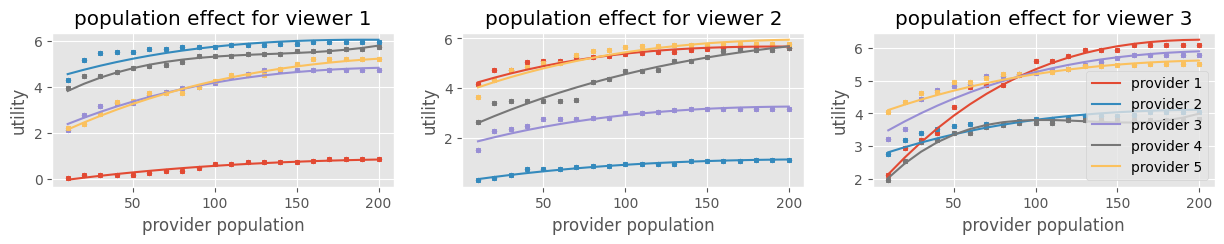

In [49]:
visualization_of_population_effect_main(env, n_samples_to_approximate=10)

  0%|          | 0/1 [00:00<?, ?it/s]

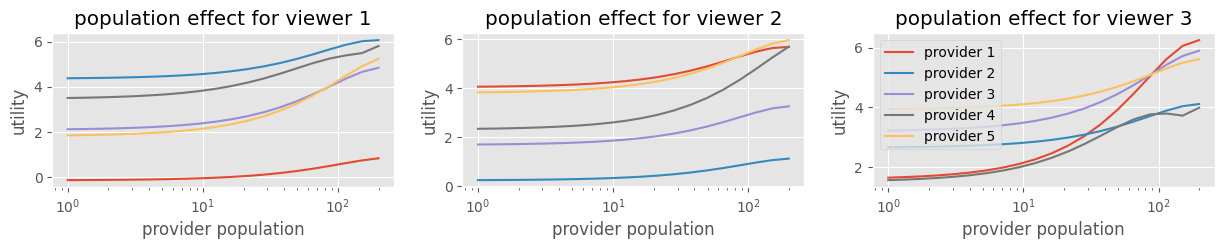

In [50]:
visualization_of_population_effect(env)

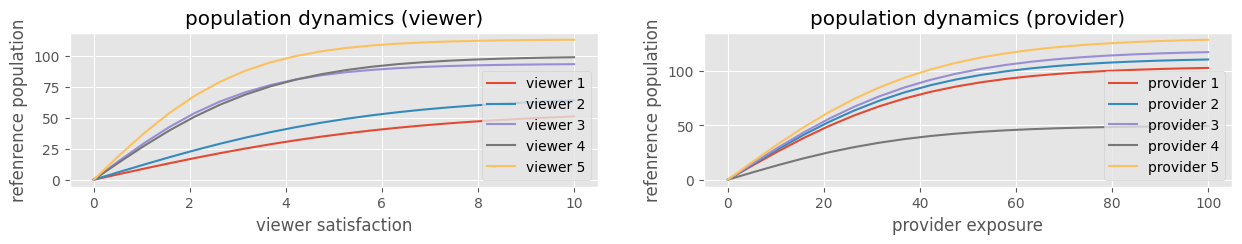

In [51]:
visualization_of_population_dynamics(env)

In [52]:
torch.manual_seed(12345)
initial_user_population = torch.clip(torch.normal(torch.full((env.n_user_groups, ), 20.), torch.full((env.n_user_groups, ), 10.)), min=10.)
initial_content_population = torch.clip(torch.normal(torch.full((env.n_content_groups, ), 20.), torch.full((env.n_content_groups, ), 10.)), min=10.)

In [53]:
# long-short tradeoff
betas = torch.linspace(0.0, 1.0, 6)
long_short_logs = main(
    env,
    initial_user_population,
    initial_content_population,
    betas,
    policy_type="long_short_tradeoff",
    n_steps=300,
)

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

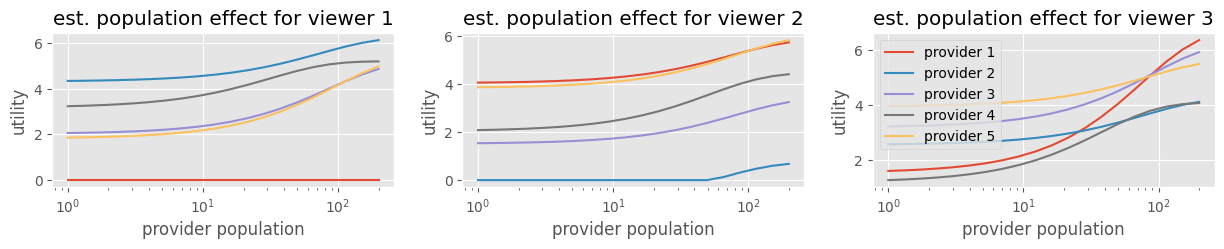

In [54]:
visualization_of_estimated_population_effect(long_short_logs[5]["dynamics_model"])

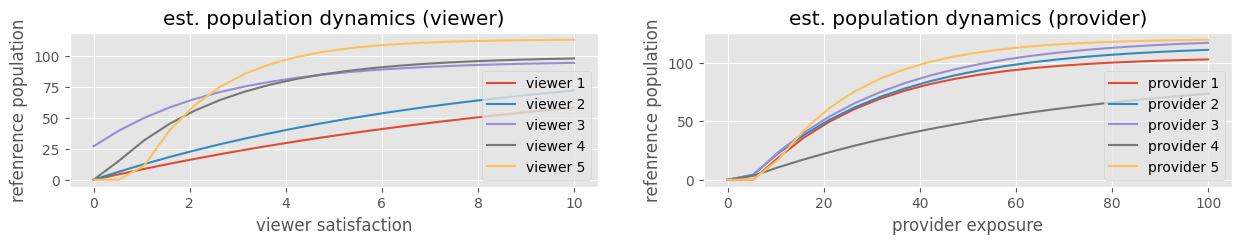

In [55]:
visualization_of_estimated_population_dynamics(long_short_logs[5]["dynamics_model"])

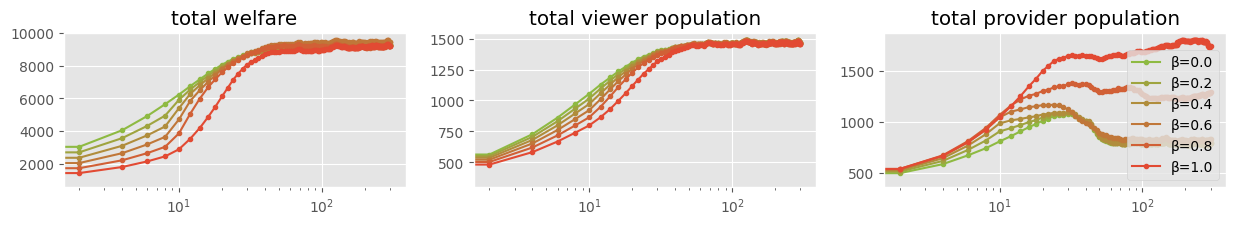

In [56]:
visualization_of_dynamics_with_varying_params(
    logs=long_short_logs,
    policy_type="long_short_tradeoff",
    params=betas,
    log_interval=2,
    use_log_scale_for_xaxis=True,
)

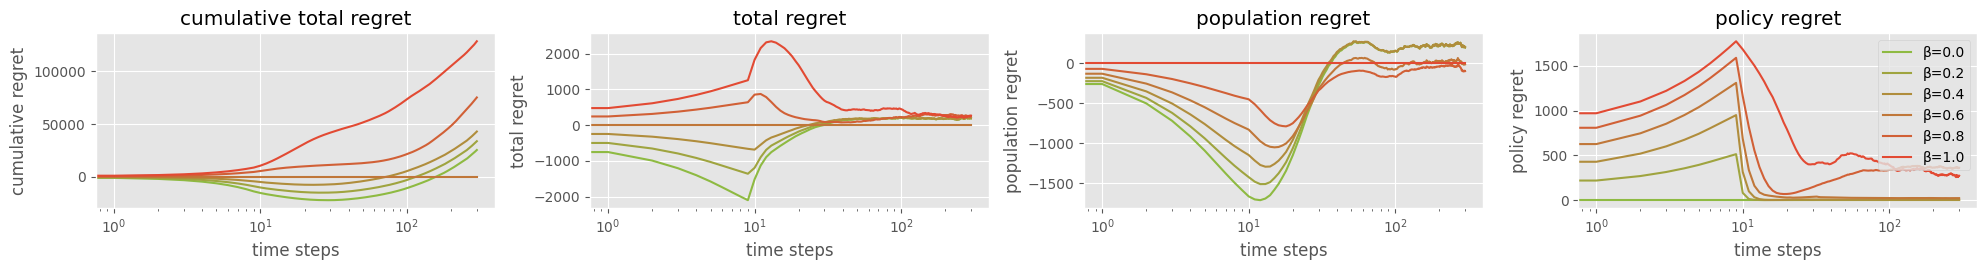

In [57]:
visualization_of_regret_with_varying_params(
    logs=long_short_logs,
    best_param_id=3,
    long_term_param_id=5,
    policy_type="long_short_tradeoff",
    params=betas,
    use_log_scale_for_xaxis=True,
)

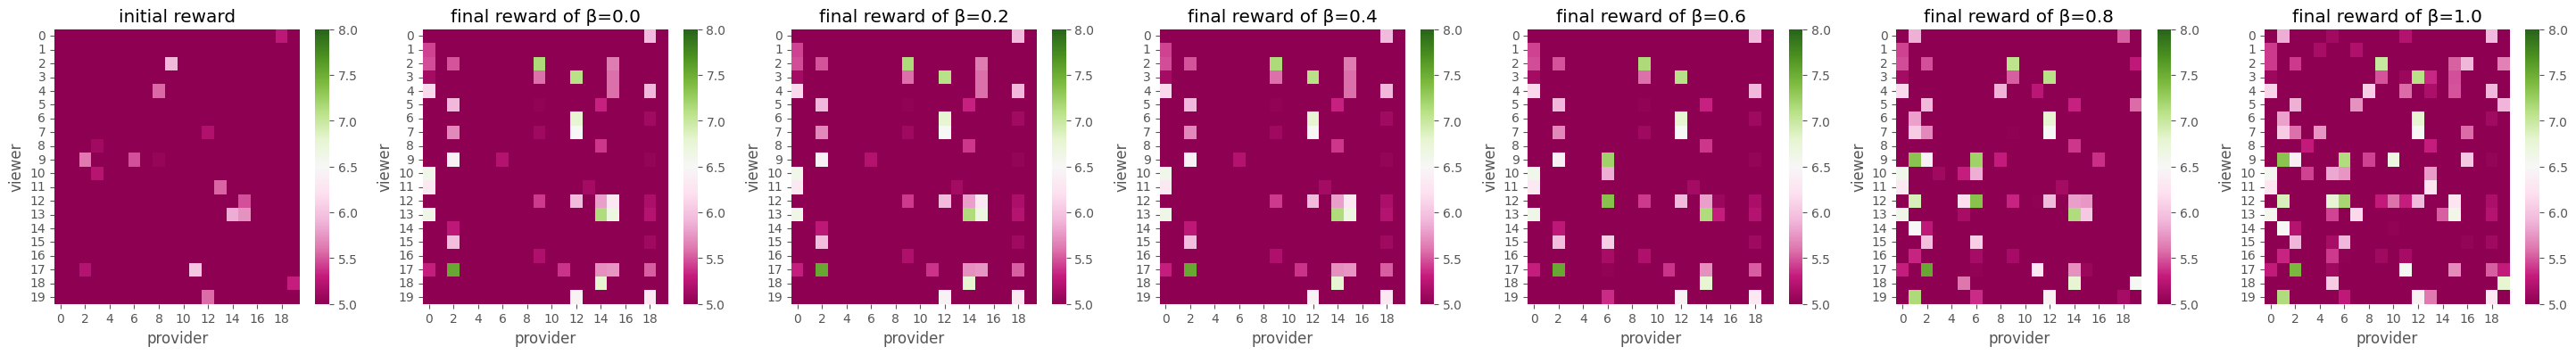

In [58]:
visualization_of_utility_matrix_with_varying_params(
    logs=long_short_logs,
    policy_type="long_short_tradeoff",
    params=betas,
)

In [59]:
# epsilon-greedy
epsilons = torch.linspace(0.0, 1.0, 6)
epsilon_greedy_logs = main(
    env,
    initial_user_population,
    initial_content_population,
    epsilons,
    policy_type="epsilon_greedy",
    n_steps=300,
)

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

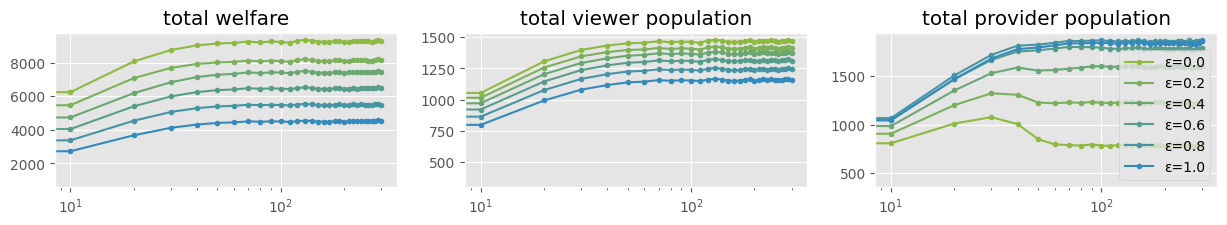

In [60]:
visualization_of_dynamics_with_varying_params(
    logs=epsilon_greedy_logs,
    policy_type="epsilon_greedy",
    params=epsilons,
    log_interval=10,
    use_log_scale_for_xaxis=True,
)

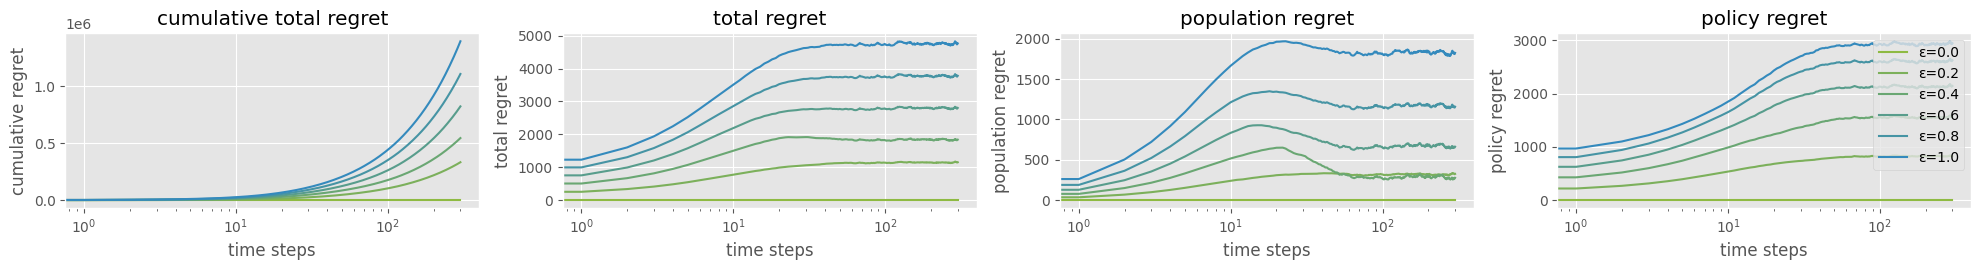

In [61]:
visualization_of_regret_with_varying_params(
    logs=epsilon_greedy_logs,
    best_param_id=0,
    long_term_param_id=0,
    policy_type="epsilon_greedy",
    params=epsilons,
    use_log_scale_for_xaxis=True,
)

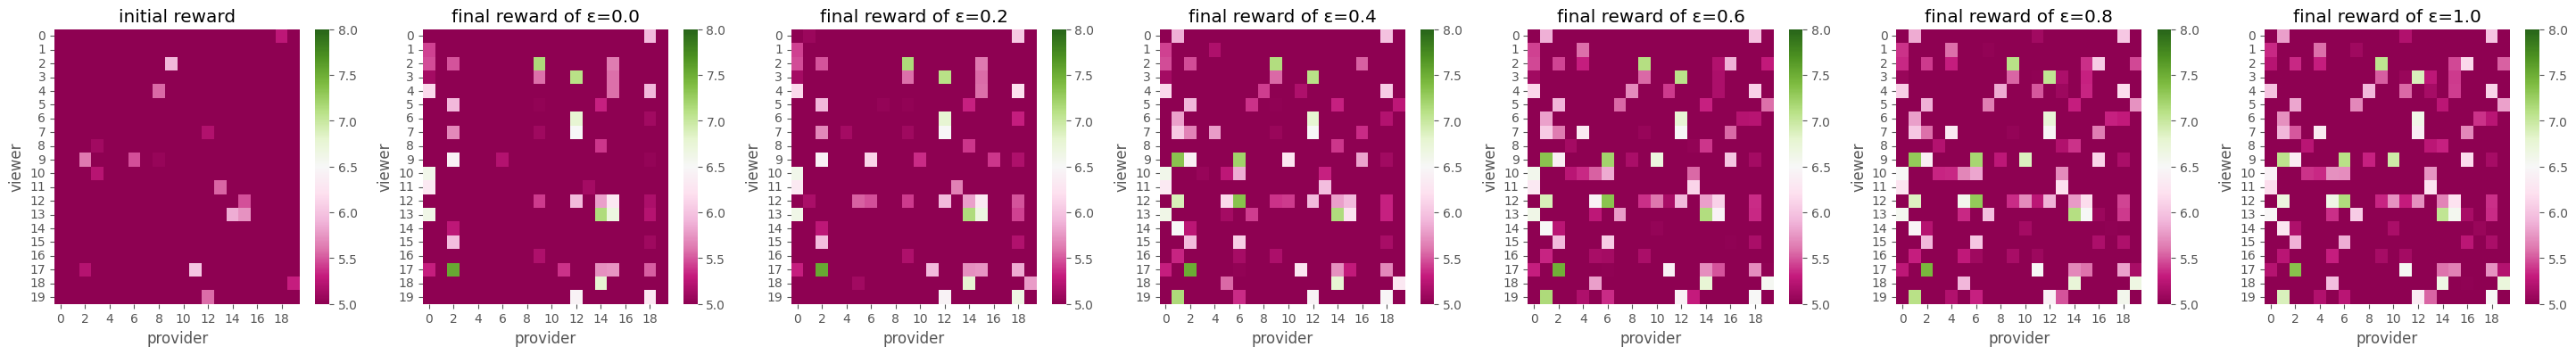

In [62]:
visualization_of_utility_matrix_with_varying_params(
    logs=epsilon_greedy_logs,
    policy_type="epsilon_greedy",
    params=epsilons,
)

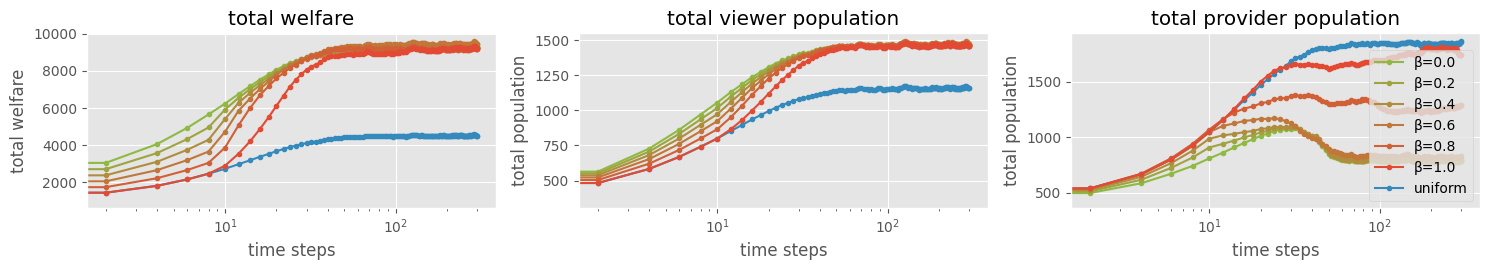

In [63]:
visualization_of_dynamics_main_text(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    params=betas,
    log_interval=2,
    use_log_scale_for_xaxis=True,
)

In [66]:
best_long_short_param_id = 3
best_epsilon_greedy_param_id = 0

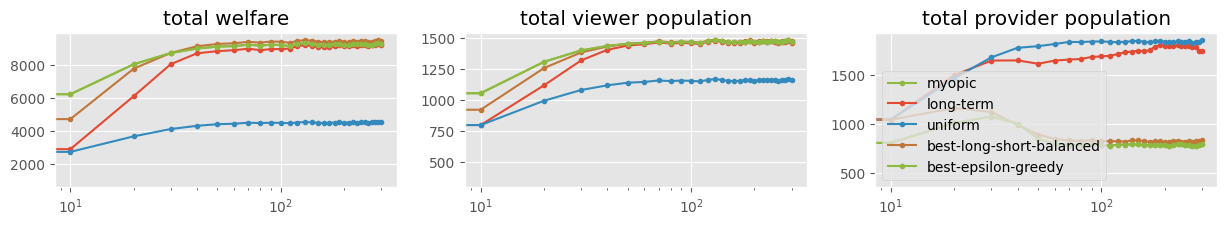

In [67]:
visualization_of_dynamics_with_representative_methods(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    best_long_short_param_id=best_long_short_param_id,
    best_epsilon_greedy_param_id=best_epsilon_greedy_param_id,
    log_interval=10,
    use_log_scale_for_xaxis=True,
)

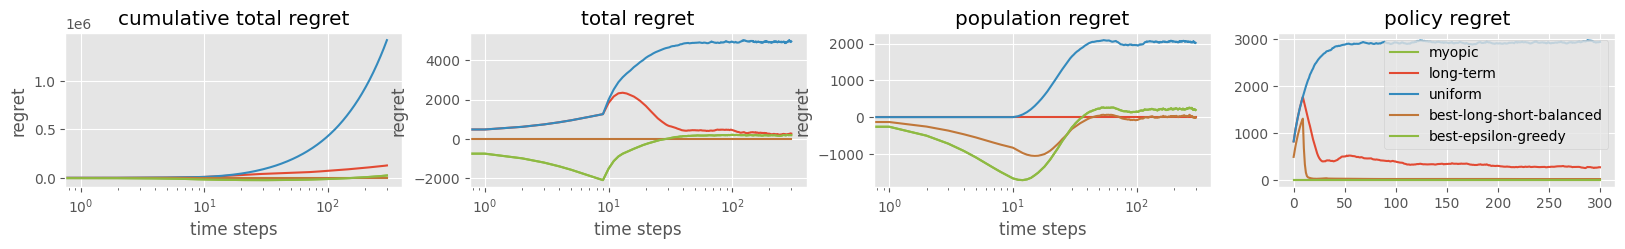

In [68]:
visualization_of_regret_with_representative_methods(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    best_long_short_param_id=best_long_short_param_id,
    best_epsilon_greedy_param_id=best_epsilon_greedy_param_id,
    use_log_scale_for_xaxis=True,
)

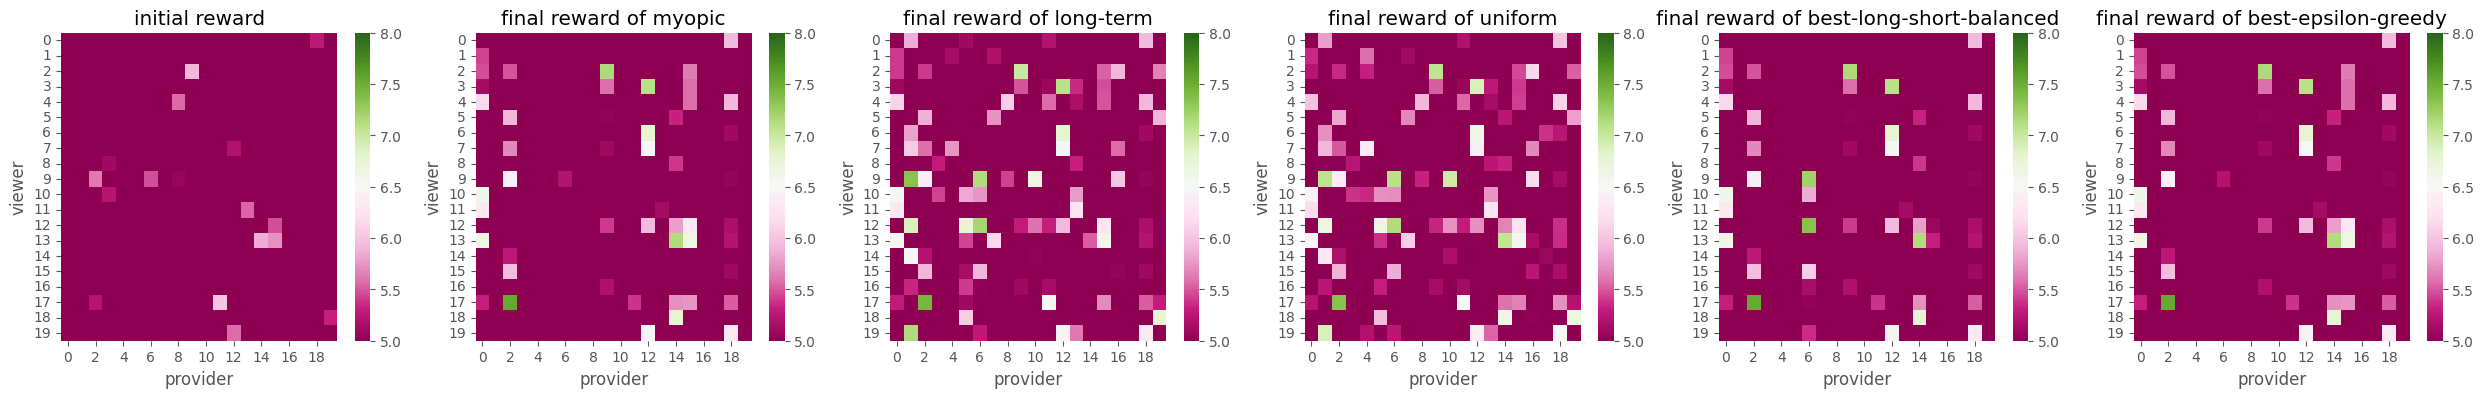

In [69]:
visualization_of_utility_matrix_with_representitive_methods(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    best_long_short_param_id=best_long_short_param_id,
    best_epsilon_greedy_param_id=best_epsilon_greedy_param_id,
)